
## NIO and cost






## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')



In [22]:

## !pip install xgboost
## !pip install onnxmltools
## !pip install onnxruntime
## !pip install pandas
## !pip install scikit-learn
## !pip install matplotlib
## !pip install seaborn
## !pip install mlxtend
## ! pip install skl2onnx



In [23]:


import torch
import numpy as np
import pandas as pd
import sklearn
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
import math
import seaborn as sns
import random
import functorch


import torch.optim as optim


from numpy.random import normal
from scipy.stats import norm
import scipy.stats as stats
from numpy import hstack
from numpy import vstack
from numpy import exp
from sklearn.neighbors import KernelDensity

##from typing import Optional

from torch import Tensor


from torch.utils.data import TensorDataset, DataLoader

from mlxtend.plotting import heatmap

## coefficient of determination (R**2)
from sklearn.metrics import r2_score

np.set_printoptions(suppress=True)
torch.set_printoptions(sci_mode=False)

import os, json, time, uuid


from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score





In [24]:


import xgboost as xgb
from xgboost import XGBClassifier, XGBRegressor, DMatrix, train as train_xgb
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import onnxmltools
from onnxmltools.convert.xgboost.operator_converters.XGBoost import (
    convert_xgboost)
from onnxmltools.convert import convert_xgboost as convert_xgboost_booster


from zipfile import ZipFile
from skl2onnx.common.data_types import FloatTensorType
from skl2onnx import convert_sklearn, to_onnx, update_registered_converter
from skl2onnx.common.shape_calculator import (
    calculate_linear_classifier_output_shapes,
    calculate_linear_regressor_output_shapes)


# Import the ONNX runtime environment
import onnxruntime as rt




In [25]:

import PDFshapingUtils as PDF_tk


In [26]:

PDFshapingOBJ = PDF_tk.PDFshapingUtils()


In [27]:

PDFshapingOBJ.read_csv_file_with_pandas('CFD.16.2025.csv')


In [28]:

## Ty suggested fix where 0 needs to be 300

PDFshapingOBJ.CFD_raw_data["i_h2_temp"] = PDFshapingOBJ.CFD_raw_data["i_h2_temp"].replace(0, 300)


In [29]:

PDFshapingOBJ.CFD_raw_data


,index,case name,i_h2i_rate,i_pci_rate,i_wpi_rate,i_ngi_rate,i_o2_volfract,i_ng_temp,i_h2_temp,i_hbtemp,...,o_h2o_sollos,o_feo_sollos,o_hm_rt,o_mw_rt,o_wf_rt,o_hm_h2share,o_mw_h2share,o_wf_h2share,o_prod_rt,o_fta
0,1,H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HB...,0,0,0,120,21,300,300,1200,...,20.0,44.9,122.0,264.0,687.0,31.6,26.7,63.5,4050.0,1800.0
1,2,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,18.5,52.6,122.0,265.0,684.0,27.9,23.4,60.6,4060.0,1850.0
2,3,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.6,50.9,123.0,266.0,690.0,27.7,23.5,60.8,4080.0,1850.0
3,4,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.2,124.0,268.0,690.0,27.7,23.2,60.6,4090.0,1850.0
4,5,H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HB...,0,0,0,100,21,300,300,1200,...,19.2,52.4,124.0,268.0,695.0,27.7,23.2,60.7,4110.0,1850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4994,4995,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,18.7,40.3,353.0,763.0,2190.0,34.0,20.5,56.7,11700.0,2380.0
4995,4996,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,18.7,40.7,353.0,763.0,2190.0,33.8,20.4,56.8,11700.0,2310.0
4996,4997,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1600,...,19.2,37.5,353.0,763.0,2230.0,33.6,20.4,57.1,11700.0,2380.0
4997,4998,H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_...,30,0,0,80,30,300,300,1480,...,17.6,39.8,355.0,768.0,2220.0,34.0,20.0,55.7,11800.0,2310.0


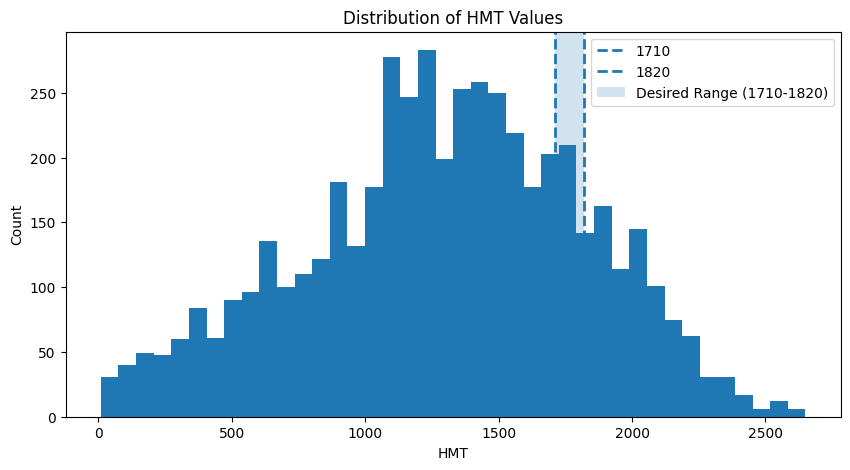

Total samples: 4999
Inside 1710-1820: 336
Percent inside: 6.72%


In [30]:

import matplotlib.pyplot as plt

df = PDFshapingOBJ.CFD_raw_data

# Histogram of HMT
plt.figure(figsize=(10,5))

plt.hist(df["o_hmt"], bins=40)

# Desired operating range
plt.axvline(1710, linestyle="--", linewidth=2, label="1710")
plt.axvline(1820, linestyle="--", linewidth=2, label="1820")

# Shade target region
plt.axvspan(1710, 1820, alpha=0.2, label="Desired Range (1710-1820)")

plt.xlabel("HMT")
plt.ylabel("Count")
plt.title("Distribution of HMT Values")
plt.legend()

plt.show()

# Optional statistics
total = len(df)
inside = ((df["o_hmt"] >= 1710) & (df["o_hmt"] <= 1820)).sum()

print(f"Total samples: {total}")
print(f"Inside 1710-1820: {inside}")
print(f"Percent inside: {100*inside/total:.2f}%")


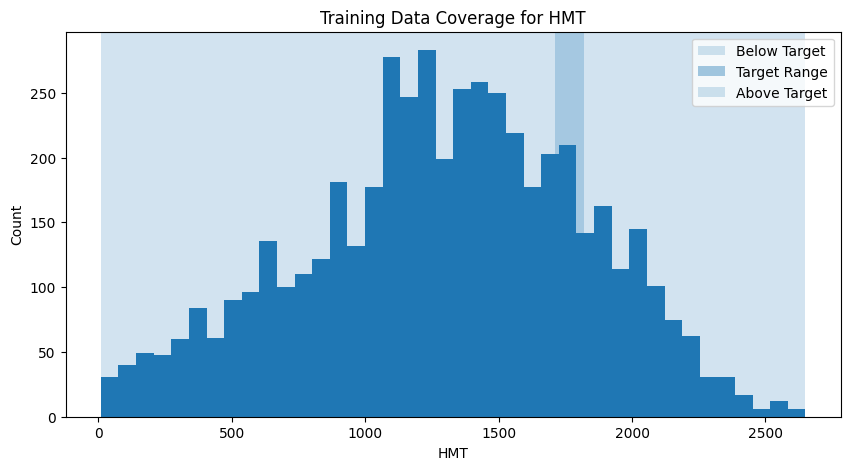

In [31]:

import matplotlib.pyplot as plt

df = PDFshapingOBJ.CFD_raw_data

hmt = df["o_hmt"]

plt.figure(figsize=(10,5))
plt.hist(hmt, bins=40)

plt.axvspan(hmt.min(), 1710, alpha=0.2, label="Below Target")
plt.axvspan(1710, 1820, alpha=0.4, label="Target Range")
plt.axvspan(1820, hmt.max(), alpha=0.2, label="Above Target")

plt.xlabel("HMT")
plt.ylabel("Count")
plt.title("Training Data Coverage for HMT")
plt.legend()

plt.show()


In [32]:

below = (df["o_hmt"] < 1710).sum()
inside = ((df["o_hmt"] >= 1710) & (df["o_hmt"] <= 1820)).sum()
above = (df["o_hmt"] > 1820).sum()

print("Below:", below, f"({100*below/len(df):.2f}%)")
print("Inside:", inside, f"({100*inside/len(df):.2f}%)")
print("Above:", above, f"({100*above/len(df):.2f}%)")


Below: 3830 (76.62%)
Inside: 336 (6.72%)
Above: 833 (16.66%)


In [33]:

PDFshapingOBJ.print_headers_list()


['index', 'case name', 'i_h2i_rate', 'i_pci_rate', 'i_wpi_rate', 'i_ngi_rate', 'i_o2_volfract', 'i_ng_temp', 'i_h2_temp', 'i_hbtemp', 'i_wind_rt', 'i_blastH2O', 'i_BdnH2O', 'i_sgi_rate', 'i_sgtemp', 'i_sgi_H2COratio', 'i_sgi_ReProRatio', 'o_tuy_velo', 'o_tuy_temp', 'o_burn', 'o_delp', 'o_co_vf', 'o_co2_vf', 'o_h2_vf', 'o_n2_vf', 'o_co_util', 'o_h2_util', 'o_tgt', 'o_coke_rt', 'o_hmt', 'o_co2_sollos', 'o_h2o_sollos', 'o_feo_sollos', 'o_hm_rt', 'o_mw_rt', 'o_wf_rt', 'o_hm_h2share', 'o_mw_h2share', 'o_wf_h2share', 'o_prod_rt', 'o_fta']
41
(0, 'index')
(1, 'case name')
(2, 'i_h2i_rate')
(3, 'i_pci_rate')
(4, 'i_wpi_rate')
(5, 'i_ngi_rate')
(6, 'i_o2_volfract')
(7, 'i_ng_temp')
(8, 'i_h2_temp')
(9, 'i_hbtemp')
(10, 'i_wind_rt')
(11, 'i_blastH2O')
(12, 'i_BdnH2O')
(13, 'i_sgi_rate')
(14, 'i_sgtemp')
(15, 'i_sgi_H2COratio')
(16, 'i_sgi_ReProRatio')
(17, 'o_tuy_velo')
(18, 'o_tuy_temp')
(19, 'o_burn')
(20, 'o_delp')
(21, 'o_co_vf')
(22, 'o_co2_vf')
(23, 'o_h2_vf')
(24, 'o_n2_vf')
(25, 'o_co_ut

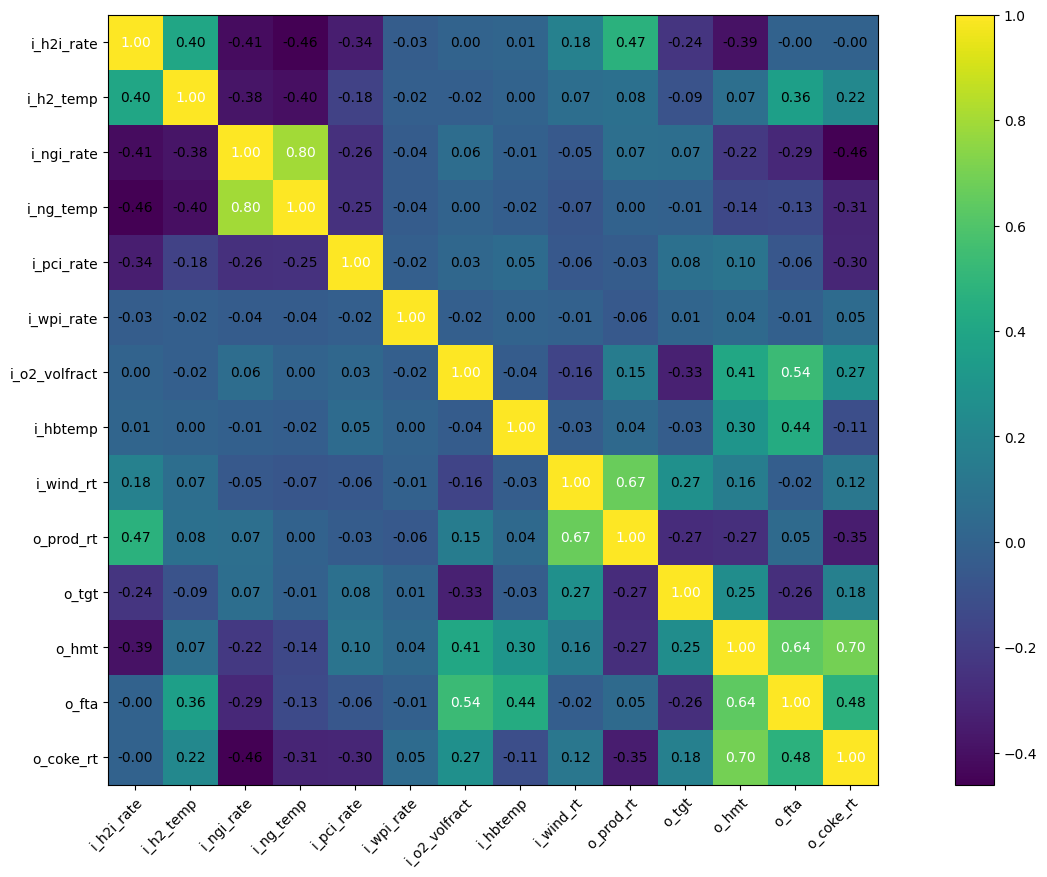

In [34]:


PDFshapingOBJ.list_of_selected_column_names = ['i_h2i_rate','i_h2_temp','i_ngi_rate','i_ng_temp','i_pci_rate',
                    'i_wpi_rate','i_o2_volfract',
                    'i_hbtemp','i_wind_rt','o_prod_rt', 'o_tgt', 'o_hmt','o_fta', 'o_coke_rt']



PDFshapingOBJ.print_correlation_coefficients()


In [35]:

PDFshapingOBJ.convert_pd_data_to_numpy()


[[1
  'H2-0_PCI-0_WPI-0_NG-120_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-7_SGI-0_SGT-0_SGC_0 '
  0 ... 63.5 4050.0 1800.0]
 [2
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-1_SGI-0_SGT-0_SGC_0 '
  0 ... 60.6 4060.0 1850.0]
 [3
  'H2-0_PCI-0_WPI-0_NG-100_O2-21_NGT-300_H2T-0_HBT-1200_WR-195_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  0 ... 60.8 4080.0 1850.0]
 ...
 [4997
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1600_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 57.1 11700.0 2380.0]
 [4998
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-3_SGI-0_SGT-0_SGC_0 '
  30 ... 55.7 11800.0 2310.0]
 [4999
  'H2-30_PCI-0_WPI-0_NG-80_O2-30_NGT-300_H2T-300_HBT-1480_WR-230_MHB-5.7_BM-5_SGI-0_SGT-0_SGC_0 '
  30 ... 56.2 11800.0 2310.0]]
(4999, 41)


In [36]:

PDFshapingOBJ.gen_X_y_for_selected_indeces(  
                   inputs = [  2, 3, 5, 6, 8, 9, 10   ] , 
                   outputs= [ 27, 29, 39, 40, 28 ]   
)


## inputs = [ 2, 3, 5, 6, 8, 9, 10  ]          ## the full 7



7
5


In [37]:

print(PDFshapingOBJ.X.shape)
print(PDFshapingOBJ.y.shape)


(4999, 7)
(4999, 5)


In [38]:

PDFshapingOBJ.random_seed = int( random.random() * 100  )         ## defautl is 42


In [39]:

PDFshapingOBJ.split_np_data_train_test(selected_test_size=0.2)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [40]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [41]:

'''


from sklearn.decomposition import PCA

# Instantiate PCA to reduce to 4 components
pca = PCA(n_components=4)

# Fit on training data and transform both train and test
X_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)
X_test_pca  = pca.transform(PDFshapingOBJ.X_test)

# Replace the original inputs with PCA-reduced versions
PDFshapingOBJ.X_train = X_train_pca
PDFshapingOBJ.X_test  = X_test_pca


'''


'\n\n\nfrom sklearn.decomposition import PCA\n\n# Instantiate PCA to reduce to 4 components\npca = PCA(n_components=4)\n\n# Fit on training data and transform both train and test\nX_train_pca = pca.fit_transform(PDFshapingOBJ.X_train)\nX_test_pca  = pca.transform(PDFshapingOBJ.X_test)\n\n# Replace the original inputs with PCA-reduced versions\nPDFshapingOBJ.X_train = X_train_pca\nPDFshapingOBJ.X_test  = X_test_pca\n\n\n'

In [42]:

print(PDFshapingOBJ.X_train.shape)
print(PDFshapingOBJ.X_test.shape)

print(PDFshapingOBJ.y_train.shape)
print(PDFshapingOBJ.y_test.shape)


(3999, 7)
(1000, 7)
(3999, 5)
(1000, 5)


In [43]:

PDFshapingOBJ.convert_dataset_from_np_to_torch()


In [44]:

PDFshapingOBJ.standardize_X_scales()
PDFshapingOBJ.standardize_y_scales()


In [45]:


PDFshapingOBJ.gen_Dataloader_train()

PDFshapingOBJ.train_dl



## Model Forward ( 7x4 )


In [46]:

n_inputs  = 7     ## 7
n_outputs = 5




#############################################################
##   F1      plus       F2
## Linear     +      Nonlinear

class F1plusF2_SIO_Forward(nn.Module):
    ## initialize the layers
    def __init__(self, x_means, x_deviations, y_means, y_deviations,  device='cuda'):
        super().__init__()
        self.device = device
        
        ## self.x_means      = x_means
        ## self.x_deviations = x_deviations
        ## self.y_means      = y_means
        ## self.y_deviations = y_deviations
        
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)
        
        
        
        ## F1
        self.f1_linear1 = nn.Linear(n_inputs, n_outputs)       
        
        ## F2
        self.f2_linear1 = nn.Linear(n_inputs, 10)
        self.f2_act1    = nn.Tanh()   ## nn.Sigmoid()    ## Tanh()    nn.ReLU()                 
        self.f2_linear2 = nn.Linear(10, n_outputs)       
        self.f2_dropout = nn.Dropout(0.25)
        
        # Move model to device
        self.to(self.device)
        
        
    ## perform inference
    def forward(self, x):
        x = x.to(self.device)
        x = (x - self.x_means) / self.x_deviations
        
        ## F1
        f1 = self.f1_linear1(x)
        
        ## F2
        f2 = self.f2_linear1(x)
        f2 = self.f2_act1(f2)
        f2 = self.f2_dropout(f2)
        f2 = self.f2_linear2(f2)
        
        
        y_scaled   = f1 + f2
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        ##   y_descaled = torch.clamp(  y_descaled, min=0.0  )
        
        return y_descaled, y_scaled
    




In [47]:

n_inputs  = 7    ## 7
n_outputs = 5





    
class ResidualNet_Forward(nn.Module):
    def __init__(self, x_means, x_deviations, y_means, y_deviations, dropout_rate=0.1, device='cuda'):
        
        super().__init__()
        self.device = device
        
        self.x_means      = x_means.to(self.device)
        self.x_deviations = x_deviations.to(self.device)
        self.y_means      = y_means.to(self.device)
        self.y_deviations = y_deviations.to(self.device)

     
        self.fc1  = nn.Linear(n_inputs, 64)
        self.act1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(64, 64)
        self.act2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(64, n_outputs)

        # If input_dim ≠ 64, project for residual addition
        self.input_proj = nn.Linear(n_inputs, 64) if n_inputs != 64 else nn.Identity()
        
        # Move model to device
        self.to(self.device)
        

    def forward(self, x):
        x  = x.to(self.device)
        x  = (x - self.x_means) / self.x_deviations
        x0 = self.input_proj(x)
        x1 = self.dropout1(self.act1(self.fc1(x)))
        x2 = self.dropout2(self.act2(self.fc2(x1)))
        x_res = x2 + x0
        y_scaled = self.fc3(x_res)
        y_descaled = y_scaled * self.y_deviations + self.y_means
        
        return y_descaled, y_scaled
    

    


In [48]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## model_Forward     = F1plusF2_SIO_Forward(

model_Forward     =     F1plusF2_SIO_Forward(
                         PDFshapingOBJ.x_means, 
                         PDFshapingOBJ.x_deviations, 
                         PDFshapingOBJ.y_means, 
                         PDFshapingOBJ.y_deviations,
                         device=device  # pass device into the model
    
)

optimizer = optim.Adam(model_Forward.parameters(), lr=0.001)
loss_fn   = nn.MSELoss()



In [49]:

model_Forward.train()

for epoch in range(1000):
    for xb, yb in PDFshapingOBJ.train_dl:
        
        xb = xb.to(model_Forward.device)
        yb = yb.to(model_Forward.device)
        
        optimizer.zero_grad()
        pred_descaled, pred_scaled = model_Forward(xb)
        
        loss = loss_fn(pred_scaled, yb)
        loss.backward()
        optimizer.step()
    if epoch % 100 == 0:
        print(epoch, ".....", loss.item() ) 
    



0 ..... 0.42891836166381836
100 ..... 0.21239131689071655
200 ..... 0.19326014816761017
300 ..... 0.16925208270549774
400 ..... 0.07469810545444489
500 ..... 0.6201648712158203
600 ..... 0.36515626311302185
700 ..... 0.18843966722488403
800 ..... 0.17262041568756104
900 ..... 0.5401919484138489


In [50]:

print("=== SANITY CHECK: SCALING ===")
print("y_means:", PDFshapingOBJ.y_means)
print("y_deviations:", PDFshapingOBJ.y_deviations)

print("===============================================")

print("x_means:", PDFshapingOBJ.x_means)
print("x_deviations:", PDFshapingOBJ.x_deviations)


=== SANITY CHECK: SCALING ===
y_means: tensor([[  97.4472, 1297.0248, 8448.6514, 2306.6194,  417.3519]])
y_deviations: tensor([[  50.4709,  523.2410, 1515.3802,  212.9969,   49.7390]])
x_means: tensor([[  12.5731,   18.9852,   41.1463,   25.6207,  414.7787, 1437.9795,
          198.6672]])
x_deviations: tensor([[ 15.3322,  45.9503,  46.7040,   3.3302, 270.9260, 158.1259,  26.3679]])


In [51]:

print(PDFshapingOBJ.y_means -  PDFshapingOBJ.y_deviations)
print(PDFshapingOBJ.y_means +  PDFshapingOBJ.y_deviations)


tensor([[  46.9763,  773.7838, 6933.2710, 2093.6226,  367.6129]])
tensor([[ 147.9182, 1820.2657, 9964.0312, 2519.6162,  467.0909]])


In [52]:

print(PDFshapingOBJ.x_means -  PDFshapingOBJ.x_deviations)
print(PDFshapingOBJ.x_means +  PDFshapingOBJ.x_deviations)


tensor([[  -2.7591,  -26.9650,   -5.5578,   22.2905,  143.8527, 1279.8535,
          172.2993]])
tensor([[  27.9053,   64.9355,   87.8503,   28.9508,  685.7047, 1596.1055,
          225.0350]])


In [53]:

import numpy as np
from numpy.linalg import norm

# --- distance function ---
def euclid(a, b):
    return norm(a - b)



## Costs




## Inputs



(2, 'i_h2i_rate')

(3, 'i_pci_rate')

(5, 'i_ngi_rate')

(6, 'i_o2_volfract')

(8, 'i_h2_temp')

(9, 'i_hbtemp')

(10, 'i_wind_rt')


## Outputs


* desired output requirements 


(27, 'o_tgt')

(29, 'o_hmt')

(39, 'o_prod_rt')

(40, 'o_fta')

(28, 'o_coke_rt')




In [54]:



def cost_func_h2i_rate(H2_rate=10, PCI_rate=25, H2_temp=600):
    
    E22        = H2_rate
    E23        = PCI_rate
    E26        = H2_temp
    
    
    ## E22        = 10       ## Starter variable  H2 rate
    ## E23        = 25       ## Starter variable PCI rate
    ## E26        = 600      ## Starter variable H2 temp
    
    ############################
    
    E6         = 0.0143 * 0.02
    
    H6         = E6 * E26
    
    E4         = 2
    
    E5         = E4 + H6
    
    
    
    H2_ambient =  E4 * E22
    H2_heated  =  E5 * E23
    H2_temp    =  E6 * E26
    
    
    
    
    result = H2_ambient + H2_heated + H2_temp
    
    return result



cost_func_h2i_rate()



74.4616

In [134]:

## Oxygen Enrichment in Wind



def cost_func_o2_volfract( wind_rate=195, o2=0.215, prod_rate=5775):
    
    o2 = o2 / 100.0
    
    
    '''
    print("wind_rate=195")
    print("o2=0.215")
    print("prod_rate=5775")
    
    print(wind_rate)
    print(o2)
    print(prod_rate)
    '''
    
    
    E20          = wind_rate
    E25          = o2 
    E19          = prod_rate 
    
    ## E20          = 195            ## Starter variable wind rate
    ## E25          = 0.215          ## Starter variable O2 
    ## E19          = 5775           ## Starter variable production rate 
    
    ######################################
    
    H25          = (E25 - 0.21) * E20
    
    
    K25          = H25 * 60 * 24
    
    N25          = K25 / E19
    
    E9           = 0.01 * 1000
    
    result       = E9 * N25
    
    
    return result



cost_func_o2_volfract()



-101.06368831168831

In [135]:




def cost_func_pci_rate(PCI_rate=25):
    
    E23         = PCI_rate
    
    ## E23         = 25        ## Start variable PCI rate
    
    #########################
    
    E7          = 0.3
    
    result      = E7 * E23
    
    return result



cost_func_pci_rate()



7.5

In [136]:


def cost_func_ngi_rate( NG_rate=70 ):
    
    E24    = NG_rate
    
    ## E24    = 70         ## Start variable - NG rate
    
    #############################
    
    
    E8     = 0.20
    
    result = E8 * E24
    
    
    return result



cost_func_ngi_rate()


14.0

In [137]:



def cost_func_coke_rate( coke_rate=470 ):
    
    
    E21         = coke_rate
    
    ## E21         = 470      ## Start variable coke rate
    
    ########################
    

    E12         = 0.45
    
    result      = E12 * E21 
    
    return result


cost_func_coke_rate()


211.5

In [138]:



def cost_func_wind_rate( wind_rate=195, prod_rate=5775 ):
    
    
    E20       = wind_rate
    E19       = prod_rate
    
    
    ## E20       = 195         ## start variable wind rate
    ## E19       = 5775        ## start variable production rate
    
    ##########################
    

    E11       = 0.1
    
    
    H20       = E20 * 60
    K20       = H20 * 24
    
    
    N20       = K20 / E19
    
    result    = E11 * N20
    
    return result



cost_func_wind_rate()


4.862337662337662

In [139]:

def calculate_new_loss_costs_equations(x_temp, y_DEscaled):
    
    ## x_temp
    ## "i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
    
    ## y_DEscaled
    ## "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"
    
    
    ## print( x_temp.shape )
    ## print( y_DEscaled.shape )
    
    ##################################################################
    
    
    ## H2_rate=10, PCI_rate=25, H2_temp=600
    ## aa = cost_func_h2i_rate( x_temp[:,0], x_temp[:,1], x_temp[:,4])
    
    ##  wind_rate=195, o2=0.215, prod_rate=5775
    ## bb = cost_func_o2_volfract( x_temp[:,6], x_temp[:,3], y_DEscaled[:,2])
    
    ## PCI_rate=25
    ## cc = cost_func_pci_rate( x_temp[:,1] )
    
    ## NG_rate=70
    ## dd = cost_func_ngi_rate( x_temp[:,2] )
    
    ## coke_rate=470
    ## ee = cost_func_coke_rate( y_DEscaled[:,4] )
    
    ## wind_rate=195, prod_rate=5775
    ## ff = cost_func_wind_rate( x_temp[:,6], y_DEscaled[:,2] )
    
    ####################################################################
    
    res = 0.0  ## + aa + bb + cc + dd + ee + ff
    
    
    return res



## Now add Costs


In [140]:

def regularize_z(z, strength=1e-3):
    
    return strength * torch.sum(z**2)


In [141]:

def soft_box_penalty(x, lower, upper, strength=1.0):     ## strength=10.0
    
    return strength * ((torch.relu(lower - x) ** 2).sum() + (torch.relu(x - upper) ** 2).sum())


In [142]:

def soft_box_penalty2(x, lower, upper, beta=0.01):
    
    # original constraint penalty
    violation = (torch.relu(lower - x)**2 + torch.relu(x - upper)**2).sum()
    
    # NEW: center stabilizer
    center      = (lower + upper) / 2
    center_pull = ((x - center)**2).mean()
    
    return violation + beta * center_pull


In [143]:

clamp_min = torch.tensor([[   0,   0,   0,    21,   300,   1200, 150 ]])     ## from Ty
clamp_max = torch.tensor([[ 300, 300, 300,    90,  1200,   1500, 220 ]])


get_x_from_z = lambda z: clamp_min + (clamp_max - clamp_min) * torch.sigmoid(z)


In [144]:

##                                   1710
y_clamp_min = torch.tensor([[  100,  1710,   6400,    2000,   200 ]])     ## from Ty
y_clamp_max = torch.tensor([[  150,  1820,   6600,    2600,   500 ]])


y_clamp_min_normalized =  (y_clamp_min  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
y_clamp_max_normalized =  (y_clamp_max  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations


In [145]:

def wrapped_model(x):
    y_descaled, _ = model_Forward(x)
    return y_descaled  



In [146]:

'''

price_real    = np.array([4.0, 0.24, 0.17, 0.0, 0.0, 0.0, 0.0])
price_real    = torch.tensor(price_real, dtype=torch.float32)

price_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.25])
price_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)


'''



'\n\nprice_real    = np.array([4.0, 0.24, 0.17, 0.0, 0.0, 0.0, 0.0])\nprice_real    = torch.tensor(price_real, dtype=torch.float32)\n\nprice_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.25])\nprice_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)\n\n\n'

In [147]:


## "i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    
## "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt"


price_real    = np.array([0.0, 0.3, 0.20, 0.0, 0.0, 0.0, 0.0])
price_real    = torch.tensor(price_real, dtype=torch.float32)

price_real_y5 = np.array([0.0, 0.0, 0.0, 0.0, 0.45])
price_real_y5 = torch.tensor(price_real_y5, dtype=torch.float32)


model_Forward.eval()


for p in model_Forward.parameters():
    p.requires_grad = False



In [148]:


## lambda_cost = 0.0

dist_method_A = []
dist_method_B = []
cost_diffs    = [] 
cost_diff     = 0

actual_pred_cost = []
actual_real_cost = []

percent_diffs = []
percent_diff  = 0 

learning_rate = 0.01        ## 0.001      ## 1e-5


In [149]:

def print_losses(j, cost_pred, x_temp_pred_np, cost_real, loss, loss_main, loss_cost, loss_ranges, 
                   new_loss_costs_equations, loss_hmt_norm):
    '''
    print(f"iteration {j}")
    print(f"pred cost: {cost_pred:.2f}  " ) ## "...H2, PCI, NGI:", x_temp_pred_np[:,:3] )
    print( "real cost:", cost_real)
    print( "                   loss_main(MSE)",     loss_main.item()        )
    print( "                       loss_ranges",    loss_ranges.item() )
    print("                      loss_hmt_norm",  loss_hmt_norm.item() )
    print( "                       loss_cost",      loss_cost.item() )
    print("                new_l_costs_equati", new_loss_costs_equations.item())
    print( "                       total loss",     loss.item()      )

    ## print( "                       loss_coke",  loss_coke.item() )
    '''
    
    ##############
    
    print(f"\nITERATION {j}")
    print("=" * 50)

    print(f"*** COSTS ***")
    print(f"Pred Cost : {cost_pred.item():10.2f}")
    print(f"Real Cost : {cost_real.item():10.2f}")

    print("\n*** LOSSES ***")

    metrics = [
        ("Loss Main (MSE)", loss_main.item()),
        ("Loss Ranges", loss_ranges.item()),
        ("Loss HMT Norm", loss_hmt_norm.item()),
        ("Loss Cost", loss_cost.item()),
        ("Cost Equation", new_loss_costs_equations),
        ("Total Loss", loss.item()),
    ]

    for name, value in metrics:
        print(f"{name:25s} {value:12.2f}")
    
    
   
 

In [150]:

PDFshapingOBJ.y_test[3]


array([  79.4, 1770. , 6090. , 2280. ,  467. ], dtype=float32)

In [151]:



import numpy as np

Y = PDFshapingOBJ.y_test
X = PDFshapingOBJ.X_test

# y2 (HMT) is column 1
y2 = Y[:, 1]

y2_min = 1710
y2_max = 1820
y2_center = (y2_min + y2_max) / 2.0  # 1765

# Rank:
# 1. Values inside range come first
# 2. Among those, closest to center (1765) come first
# 3. Outside values come after, ordered by distance from range

score = np.where(
    (y2 >= y2_min) & (y2 <= y2_max),
    np.abs(y2 - y2_center),
    1000 + np.maximum(y2_min - y2, 0) + np.maximum(y2 - y2_max, 0)
)

idx = np.argsort(score)

X_ranked = X[idx]
Y_ranked = Y[idx]

#print(Y_ranked[:20])



PDFshapingOBJ.y_test = Y_ranked
PDFshapingOBJ.X_test = X_ranked 


In [152]:

def final_data_gathering(i, wrapped_model, x_temp_pred_np, x_real_np ):
    
    print(i)
    print('*******************************************************')
    
    
    if i == 1:
        percent_errors = [ [] for _ in range(5) ]  # one list per output

    y_pred_np = wrapped_model(
                    torch.from_numpy( 
                         x_temp_pred_np
                    )).detach().numpy().flatten()
    
    y_real_np = wrapped_model(
                    torch.from_numpy(
                          x_real_np
                    )).detach().numpy().flatten()

    # % error per variable
    pct = (y_pred_np - y_real_np) / (y_real_np + 1e-8) * 100

    for k in range(5):
         percent_errors[k].append( pct[k] )
    return percent_errors


In [153]:

def print_some_values(i, x_temp_pred_np,  x_real_np, wrapped_model, PDFshapingOBJ  ):
    the_cols = "    i_h2i_rate,   i_pci_rate,   i_ngi_rate, i_o2_volfract,    i_h2_temp, i_hbtemp, i_wind_rt"
    '''
    print("...")
    print("...")
    print("...")
    print( the_cols )
    print( "pred" )
    print( x_temp_pred_np[0] )
    print( "real" )
    print( x_real_np )
    print("...")
    
    
    print( "o_tgt, o_hmt, o_prod_rt, o_fta, o_coke_rt" )
    print( "y pred" )
    print( wrapped_model(torch.from_numpy(x_temp_pred_np))   )
    print( "y real" )
    print(  PDFshapingOBJ.y_test[i]  )
    ## print( " this is a predicted y from the real x " )
    ## print( wrapped_model(torch.from_numpy(x_real_np))   )
    '''
    
    #################
    
    '''
    print(x_temp_pred_np)
    print(x_temp_pred_np.shape)
    print(x_real_np)
    print(x_real_np.shape)
    '''
    
    x_pred = np.round(x_temp_pred_np[0], 1)
    
    ##x_real = np.round(x_real_np, 1)
    x_real = np.round(x_real_np[0], 1)
    
    '''
    print(x_pred)
    print(x_pred.shape)
    print(x_real)
    print(x_real.shape)
    '''

    y_pred = wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().cpu().numpy()[0]
    y_pred = np.round(y_pred, 1)
    
    ## print(y_pred)
    ## print(y_pred.shape)
    

    y_real = np.round(PDFshapingOBJ.y_test[i], 1)
    ## print(y_real)
    ## print(y_real.shape)


    print("\nINPUTS")
    print(f"{'Variable':15s} {'Pred':>10s} {'Real':>10s}")
    print("-"*38)

    cols_x = [
        "h2i_rate","pci_rate","ngi_rate",
        "o2_volfrac","h2_temp","hbtemp","wind_rt"
    ]

    for c,p,r in zip(cols_x, x_pred, x_real):
        print(f"{c:15s} {p:10.1f} {r:10.1f}")

    print("\nOUTPUTS")
    print(f"{'Variable':15s} {'Pred':>10s} {'Real':>10s}")
    print("-"*38)

    cols_y = [
        "tgt","hmt","prod_rt","fta","coke_rt"
    ]

    for c,p,r in zip(cols_y, y_pred, y_real):
        print(f"{c:15s} {p:10.1f} {r:10.1f}")


In [154]:


PDFshapingOBJ.y_test[:5]



array([[ 188., 1770., 7510., 2050.,  457.],
       [ 208., 1760., 6670., 2130.,  458.],
       [ 110., 1760., 8980., 2350.,  460.],
       [ 102., 1770., 8670., 2280.,  375.],
       [ 274., 1760., 6530., 2050.,  427.]], dtype=float32)

In [155]:

PDFshapingOBJ.X_test[:5]


array([[   0.,    0.,  120.,   27.,  300., 1200.,  230.],
       [   0.,    0.,   80.,   27.,  300., 1200.,  195.],
       [  10.,    0.,    0.,   24.,  300., 1480.,  230.],
       [   0.,  150.,    0.,   27.,  300., 1600.,  195.],
       [   0.,    0.,  120.,   21.,  300., 1600.,  230.]], dtype=float32)

In [156]:

def calculate_real_costs_for_printing(loss_cost_descaled, x_temp_descaled, x_real, target_y):
    
    x_temp_pred_np   = x_temp_descaled.detach().numpy()
    cost_pred        = loss_cost_descaled
    ## torch.dot(price_real, x_temp_descaled.squeeze()).item()
    
    #######################
    
    x_real = x_real.unsqueeze(0)
    target_y = target_y.unsqueeze(0)
    
    ##print(x_real.shape)
    ##print(target_y.shape)
    
    loss_cost_real          =     x_real @ price_real
    loss_cost_y5_real       =   target_y @ price_real_y5
        
    loss_wind_rate_real     = cost_func_wind_rate( x_real[:, 6], target_y[:, 2] )
    loss_h2i_rate  = cost_func_h2i_rate(x_real[:, 0], x_real[:, 1], x_real[:, 4])
    loss_o2_v    = cost_func_o2_volfract( x_real[:,6], x_real[:,3], target_y[:,2])
        
    loss_cost_descaled_real = loss_cost_real + loss_cost_y5_real + loss_wind_rate_real + loss_h2i_rate + loss_o2_v
    
    #######################
        
    x_real_np        = x_real.detach().numpy() 
    cost_real        = loss_cost_descaled_real
       
    return x_temp_pred_np, x_real_np, cost_pred, cost_real


In [157]:

## loss_z_reg   = regularize_z(z, strength=1e-3)



In [ ]:


w_mse   = 1.0
w_cost  = 1.0       
w_range = 1.0             
w_hmt   = 120.0        ## (if can't improve, use 20 and save notebook) - 10.0   (1710)      



for i in range(  1, PDFshapingOBJ.X_test.shape[0]  ):
    
    target_y  = torch.tensor( PDFshapingOBJ.y_test[i]   )    ## what you want y ?
    x_real    = torch.tensor( PDFshapingOBJ.X_test[i]   )    ## real x
    
    target_y_normalized  = (target_y  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
    
    
    z_init    = torch.rand((1,7))*0.2 + 0.3
    z         = torch.nn.Parameter(torch.logit(z_init))    ## this requires grad 
    optimizer = torch.optim.Adam([z], lr=learning_rate)
    
    
    for j in range(3000):              ## 2000
        
        optimizer.zero_grad()
        
        x_temp_descaled              = get_x_from_z(    z    )

        y_descaled, current_y_normalized = model_Forward( x_temp_descaled )
        
        ##########################################
        
        loss_main_norm   = torch.mean(  (current_y_normalized - target_y_normalized)**2  )
        
        ##########################################
        
        loss_ranges_norm = soft_box_penalty(current_y_normalized, y_clamp_min_normalized, y_clamp_max_normalized)
        
        ##########################################
        
        new_loss_costs_equations = 0.0
        
        loss_cost          =     x_temp_descaled @ price_real
        loss_cost_y5       =          y_descaled @ price_real_y5
        
        
        loss_wind_rate = cost_func_wind_rate( x_temp_descaled[:, 6], y_descaled[:, 2] )
        loss_h2i_rate  = cost_func_h2i_rate(x_temp_descaled[:, 0], x_temp_descaled[:, 1], x_temp_descaled[:, 4])
        loss_o2_vol    = cost_func_o2_volfract( x_temp_descaled[:,6], x_temp_descaled[:,3], y_descaled[:,2])
        
        loss_cost_descaled = loss_cost + loss_cost_y5 + loss_wind_rate + loss_h2i_rate + loss_o2_vol
        
    
        ##########################################
        # HMT is index 1 (1710)
        
        y_clamp_min_temp            = torch.tensor([[  100,  1710 + 55,   6400,    2000,   200 ]])     
        y_clamp_min_temp_normalized =  (y_clamp_min_temp  - PDFshapingOBJ.y_means) /  PDFshapingOBJ.y_deviations
        
        hmt_pred         =   current_y_normalized[:, 1]
        hmt_center       =   y_clamp_min_temp_normalized[:, 1]       

        loss_hmt_norm    =      ( hmt_center - hmt_pred ) ** 2
     
        ################################################
        
 
        loss_norm     = w_mse*loss_main_norm + w_range*loss_ranges_norm  + w_hmt*loss_hmt_norm 
    
        loss_descaled = w_cost*loss_cost_descaled  
        
        loss = loss_norm + loss_descaled
        
        '''
        print("loss_main_norm", loss_main_norm.item() )
        print("loss_ranges_norm", loss_ranges_norm.item() )
        print("loss_hmt_norm", loss_hmt_norm.item() )
        print("loss_cost_descaled", loss_cost_descaled.item() )
        print("new_loss_costs_equations", new_loss_costs_equations.item() )
        print("loss", loss.item() )
        input()
        '''
        
    
        loss.backward()
        optimizer.step()
        
        #####################################################################
        #####################################################################
        #####################################################################
        #####################################################################
        
        '''
        x_temp_pred_np   = x_temp_descaled.detach().numpy()
        cost_pred        = torch.dot(price_real, x_temp_descaled.squeeze()).item()
        
        x_real_np        = x_real.detach().numpy() 
        cost_real        = np.dot(price_real, x_real_np)
        '''
        
        
        x_temp_pred_np, x_real_np, cost_pred, cost_real = calculate_real_costs_for_printing(loss_cost_descaled, 
                                                                          x_temp_descaled, x_real, target_y)
        
       
        if j % 400 == 0:           
            print_losses(j, cost_pred, x_temp_pred_np, cost_real, loss, loss_main_norm, 
                              loss_cost_descaled, loss_ranges_norm, new_loss_costs_equations, loss_hmt_norm)
        
   
        #####################################################################
        cost_diff = cost_pred - cost_real
        if cost_real > 0:                         ## handle nans
            percent_diff = cost_diff / cost_real
            percent_diffs.append(percent_diff)
        
    ###################################################################################
            
    cost_diffs.append(        cost_diff  )
    actual_pred_cost.append(  cost_pred  )
    actual_real_cost.append(  cost_real  )
      

    print_some_values(i, x_temp_pred_np,  x_real_np, wrapped_model, PDFshapingOBJ  )
    
    
    dist_method_A.append( euclid(x_temp_pred_np, x_real_np) )
    dist_method_B.append( euclid(
                    wrapped_model(torch.from_numpy(x_temp_pred_np)).detach().numpy() , 
                    wrapped_model(torch.from_numpy(x_real_np)).detach().numpy()
    ))
    
    
    ## percent_errors = final_data_gathering(i, wrapped_model, x_temp_pred_np, x_real_np )
    print(i)
    print('*******************************************************')
    




ITERATION 0
*** COSTS ***
Pred Cost :     745.05
Real Cost :     251.66

*** LOSSES ***
Loss Main (MSE)                  22.06
Loss Ranges                      62.64
Loss HMT Norm                    19.52
Loss Cost                       745.05
Cost Equation                     0.00
Total Loss                     3171.93

ITERATION 400
*** COSTS ***
Pred Cost :     481.66
Real Cost :     251.66

*** LOSSES ***
Loss Main (MSE)                  10.04
Loss Ranges                      24.85
Loss HMT Norm                     0.00
Loss Cost                       481.66
Cost Equation                     0.00
Total Loss                      516.98

ITERATION 800
*** COSTS ***
Pred Cost :     376.64
Real Cost :     251.66

*** LOSSES ***
Loss Main (MSE)                   7.01
Loss Ranges                      13.37
Loss HMT Norm                     0.01
Loss Cost                       376.64
Cost Equation                     0.00
Total Loss                      397.99

ITERATION 1200
*** COSTS *


ITERATION 1200
*** COSTS ***
Pred Cost :     339.19
Real Cost :     549.38

*** LOSSES ***
Loss Main (MSE)                   2.27
Loss Ranges                       8.57
Loss HMT Norm                     0.00
Loss Cost                       339.19
Cost Equation                     0.00
Total Loss                      350.45

ITERATION 1600
*** COSTS ***
Pred Cost :     299.69
Real Cost :     549.38

*** LOSSES ***
Loss Main (MSE)                   1.74
Loss Ranges                       5.34
Loss HMT Norm                     0.01
Loss Cost                       299.69
Cost Equation                     0.00
Total Loss                      308.30

ITERATION 2000
*** COSTS ***
Pred Cost :     275.64
Real Cost :     549.38

*** LOSSES ***
Loss Main (MSE)                   1.49
Loss Ranges                       3.88
Loss HMT Norm                     0.01
Loss Cost                       275.64
Cost Equation                     0.00
Total Loss                      282.71

ITERATION 2400
*** CO


ITERATION 2400
*** COSTS ***
Pred Cost :     266.57
Real Cost :     242.45

*** LOSSES ***
Loss Main (MSE)                   0.32
Loss Ranges                       3.29
Loss HMT Norm                     0.01
Loss Cost                       266.57
Cost Equation                     0.00
Total Loss                      271.78

ITERATION 2800
*** COSTS ***
Pred Cost :     253.52
Real Cost :     242.45

*** LOSSES ***
Loss Main (MSE)                   0.25
Loss Ranges                       2.37
Loss HMT Norm                     0.01
Loss Cost                       253.52
Cost Equation                     0.00
Total Loss                      257.59

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               5.9        0.0
pci_rate               1.1        0.0
ngi_rate              66.0       41.0
o2_volfrac            28.3       27.0
h2_temp             1129.4      300.0
hbtemp              1486.1     1448.0
wind_rt              192.6      195


ITERATION 400
*** COSTS ***
Pred Cost :     473.22
Real Cost :     243.86

*** LOSSES ***
Loss Main (MSE)                   3.95
Loss Ranges                      25.69
Loss HMT Norm                     0.00
Loss Cost                       473.22
Cost Equation                     0.00
Total Loss                      503.31

ITERATION 800
*** COSTS ***
Pred Cost :     379.65
Real Cost :     243.86

*** LOSSES ***
Loss Main (MSE)                   2.35
Loss Ranges                      15.35
Loss HMT Norm                     0.01
Loss Cost                       379.65
Cost Equation                     0.00
Total Loss                      398.24

ITERATION 1200
*** COSTS ***
Pred Cost :     323.45
Real Cost :     243.86

*** LOSSES ***
Loss Main (MSE)                   1.40
Loss Ranges                       8.08
Loss HMT Norm                     0.01
Loss Cost                       323.45
Cost Equation                     0.00
Total Loss                      334.19

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     287.76
Real Cost :     260.07

*** LOSSES ***
Loss Main (MSE)                   2.55
Loss Ranges                       6.00
Loss HMT Norm                     0.01
Loss Cost                       287.76
Cost Equation                     0.00
Total Loss                      297.95

ITERATION 2000
*** COSTS ***
Pred Cost :     268.42
Real Cost :     260.07

*** LOSSES ***
Loss Main (MSE)                   2.09
Loss Ranges                       4.21
Loss HMT Norm                     0.01
Loss Cost                       268.42
Cost Equation                     0.00
Total Loss                      276.44

ITERATION 2400
*** COSTS ***
Pred Cost :     254.51
Real Cost :     260.07

*** LOSSES ***
Loss Main (MSE)                   1.59
Loss Ranges                       2.67
Loss HMT Norm                     0.01
Loss Cost                       254.51
Cost Equation                     0.00
Total Loss                      260.28

ITERATION 2800
*** CO

...


ITERATION 400
*** COSTS ***
Pred Cost :     407.59
Real Cost :     283.63

*** LOSSES ***
Loss Main (MSE)                   3.92
Loss Ranges                      17.56
Loss HMT Norm                     0.01
Loss Cost                       407.59
Cost Equation                     0.00
Total Loss                      429.88

ITERATION 800
*** COSTS ***
Pred Cost :     309.45
Real Cost :     283.63

*** LOSSES ***
Loss Main (MSE)                   1.89
Loss Ranges                       6.75
Loss HMT Norm                     0.01
Loss Cost                       309.45
Cost Equation                     0.00
Total Loss                      319.52

ITERATION 1200
*** COSTS ***
Pred Cost :     273.90
Real Cost :     283.63

*** LOSSES ***
Loss Main (MSE)                   1.16
Loss Ranges                       3.32
Loss HMT Norm                     0.01
Loss Cost                       273.90
Cost Equation                     0.00
Total Loss                      280.00

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     266.39
Real Cost :     237.00

*** LOSSES ***
Loss Main (MSE)                   1.63
Loss Ranges                       4.74
Loss HMT Norm                     0.01
Loss Cost                       266.39
Cost Equation                     0.00
Total Loss                      274.52

ITERATION 2000
*** COSTS ***
Pred Cost :     249.99
Real Cost :     237.00

*** LOSSES ***
Loss Main (MSE)                   1.02
Loss Ranges                       2.88
Loss HMT Norm                     0.01
Loss Cost                       249.99
Cost Equation                     0.00
Total Loss                      255.24

ITERATION 2400
*** COSTS ***
Pred Cost :     235.25
Real Cost :     237.00

*** LOSSES ***
Loss Main (MSE)                   0.40
Loss Ranges                       1.49
Loss HMT Norm                     0.01
Loss Cost                       235.25
Cost Equation                     0.00
Total Loss                      238.37

ITERATION 2800
*** CO


ITERATION 2800
*** COSTS ***
Pred Cost :     230.02
Real Cost :     253.02

*** LOSSES ***
Loss Main (MSE)                   1.18
Loss Ranges                       1.08
Loss HMT Norm                     0.01
Loss Cost                       230.02
Cost Equation                     0.00
Total Loss                      233.27

INPUTS
Variable              Pred       Real
--------------------------------------
h2i_rate               2.7       20.0
pci_rate               0.8        0.0
ngi_rate              49.2        0.0
o2_volfrac            24.0       21.0
h2_temp             1165.4      900.0
hbtemp              1493.4     1480.0
wind_rt              206.3      195.0

OUTPUTS
Variable              Pred       Real
--------------------------------------
tgt                  113.7      187.0
hmt                 1720.4     1530.0
prod_rt             8034.4     6360.0
fta                 2509.7     2280.0
coke_rt              431.6      463.0
257
*******************************************


ITERATION 400
*** COSTS ***
Pred Cost :     445.75
Real Cost :     221.03

*** LOSSES ***
Loss Main (MSE)                   3.60
Loss Ranges                      20.69
Loss HMT Norm                     0.00
Loss Cost                       445.75
Cost Equation                     0.00
Total Loss                      470.63

ITERATION 800
*** COSTS ***
Pred Cost :     353.04
Real Cost :     221.03

*** LOSSES ***
Loss Main (MSE)                   1.96
Loss Ranges                      11.19
Loss HMT Norm                     0.00
Loss Cost                       353.04
Cost Equation                     0.00
Total Loss                      366.59

ITERATION 1200
*** COSTS ***
Pred Cost :     302.75
Real Cost :     221.03

*** LOSSES ***
Loss Main (MSE)                   1.06
Loss Ranges                       5.99
Loss HMT Norm                     0.01
Loss Cost                       302.75
Cost Equation                     0.00
Total Loss                      311.22

ITERATION 1600
*** COST


ITERATION 1600
*** COSTS ***
Pred Cost :     277.81
Real Cost :     608.57

*** LOSSES ***
Loss Main (MSE)                   1.39
Loss Ranges                       4.02
Loss HMT Norm                     0.01
Loss Cost                       277.81
Cost Equation                     0.00
Total Loss                      284.94

ITERATION 2000
*** COSTS ***
Pred Cost :     259.31
Real Cost :     608.57

*** LOSSES ***
Loss Main (MSE)                   1.15
Loss Ranges                       2.68
Loss HMT Norm                     0.01
Loss Cost                       259.31
Cost Equation                     0.00
Total Loss                      264.80

ITERATION 2400
*** COSTS ***
Pred Cost :     243.17
Real Cost :     608.57

*** LOSSES ***
Loss Main (MSE)                   0.93
Loss Ranges                       1.60
Loss HMT Norm                     0.01
Loss Cost                       243.17
Cost Equation                     0.00
Total Loss                      246.84


In [ ]:

avg_A = np.mean(dist_method_A)


print("Average Euclidean Distance of Xs:")
print("Method A:", avg_A)


In [ ]:

avg_B = np.mean(dist_method_B)


print("Average Euclidean Distance of Ys:")
print("Method A:", avg_B)


In [ ]:

print("average cost diff:",    np.mean(cost_diffs))
print("average percent diff:", np.mean(percent_diffs)*100, "%")


In [ ]:

better = np.sum(np.array(cost_diffs) < 0)
total  = len(cost_diffs)


print("solver cheaper in:", better/total*100, "% of cases")


In [ ]:

print(total)
print(better)


In [ ]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[0:100] ,label="real")

plt.plot( pred[0:100] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


In [ ]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[300:400] ,label="real")

plt.plot( pred[300:400] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


In [ ]:

import numpy as np
import matplotlib.pyplot as plt


# convert lists to numpy arrays
real = np.array(actual_real_cost)
pred = np.array(actual_pred_cost)



plt.figure(  figsize=(6,6)  )

plt.plot( real[700:800] ,label="real")

plt.plot( pred[700:800] ,label="pred")

plt.legend()

plt.title("Prediction vs Real")

plt.show()


In [ ]:

output_names = ['o_tgt', 'o_hmt', 'o_prod_rt', 'o_fta', 'o_coke_rt']

for k in range(5):
    plt.figure()
    plt.scatter(range(len(percent_errors[k])), percent_errors[k])
    
    plt.axhline(0)       # perfect prediction
    plt.axhline(10)      # +10% threshold
    plt.axhline(-10)     # -10% threshold
    
    plt.title(f"% Error for {output_names[k]}")
    plt.xlabel("Sample Index")
    plt.ylabel("% Difference (Pred vs Real)")
    
    plt.show()


In [ ]:

for k in range(5):
    plt.figure()
    plt.hist(percent_errors[k], bins=50)
    plt.title(f"% Error Distribution for {output_names[k]}")
    plt.xlabel("% Difference")
    plt.ylabel("Frequency")
    plt.show()


In [ ]:

for k in range(5):
    vals = np.abs(percent_errors[k])
    within_10 = np.mean(vals <= 10) * 100
    within_5  = np.mean(vals <= 5) * 100

    print(output_names[k])
    print("  within 5% :", within_5)
    print("  within 10%:", within_10)


In [ ]:

plt.figure()
plt.boxplot(percent_errors)
plt.xticks(range(1,6), output_names)
plt.axhline(10)
plt.axhline(-10)
plt.title("% Error Distribution (All Outputs)")
plt.ylabel("% Difference")
plt.show()


In [ ]:

window = 25

for k in range(5):
    vals = np.array(percent_errors[k])
    smooth = np.convolve(vals, np.ones(window)/window, mode='valid')

    plt.figure()
    plt.plot(smooth)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(f"Smoothed % Error for {output_names[k]}")
    plt.show()


In [ ]:

for k in range(5):
    vals = np.sort(np.array(percent_errors[k]))

    plt.figure()
    plt.plot(vals)
    plt.axhline(10)
    plt.axhline(-10)

    plt.title(output_names[k])
    plt.ylabel("% error")
    plt.xlabel("samples (sorted)")
    plt.show()


# 